# Lost in the Middle (LITM) — Experiments via Ollama

**Based on:** *Lost in the Middle: How Language Models Use Long Contexts* (Liu et al., TACL 2024) and follow-up work.

This notebook replicates all 9 LITM experiments using a **local Ollama model** — no API key needed.

---
### Prerequisites
```bash
# 1. Install Ollama → https://ollama.com
ollama pull llama3          # or mistral, phi3, gemma2, etc.
pip install ollama matplotlib seaborn rouge-score numpy
```
> **All experiments run locally.** Swap `OLLAMA_MODEL` below to use any model you have pulled.


##  Setup & Configuration

In [1]:
import ollama
import random, json, time, itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from rouge_score import rouge_scorer as rs_module

OLLAMA_MODEL  = "tinyllama"
OLLAMA_HOST   = "http://localhost:11434"   # default Ollama host
SEED          = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False})

print(f"Using model : {OLLAMA_MODEL}")


try:
    ollama.list()
    print("Ollama is running")
except Exception as e:
    print(f"Ollama not reachable: {e}")
    print("Start Ollama with: ollama serve")


Using model : tinyllama
Ollama is running


## Shared Utilities

In [2]:
def call_llm(prompt: str, max_tokens: int = 80) -> str:
    """Call local model and return the response text."""
    resp = ollama.chat(
        model=OLLAMA_MODEL,
        messages=[{"role": "user", "content": prompt}],
        options={"num_predict": max_tokens, "temperature": 0},
    )
    return resp["message"]["content"].strip()


def insert_at(docs, relevant_doc, position):
    """Return list with relevant_doc inserted at zero-indexed position."""
    d = docs.copy()
    d.insert(position, relevant_doc)
    return d


def build_mdqa_prompt(question, docs):
    ctx = "\n\n".join([f"Document {i+1}:\n{d}" for i, d in enumerate(docs)])
    return (
        f"Answer the question using ONLY the documents below. "
        f"Be concise — one or two words if possible.\n\n"
        f"{ctx}\n\nQuestion: {question}\nAnswer:"
    )


def gap_accuracy(acc_dict):
    """Max − min accuracy across positions. 0 = perfectly position-agnostic."""
    v = list(acc_dict.values())
    return max(v) - min(v)


# Synthetic dataset (replace with real NQ data for publication or actual research purposes)
QA_PAIRS = [
    {"question": "What is the employee ID of Dr. Neha Sharma?",
     "answer": "EMP-4821",
     "relevant_doc": "Dr. Neha Sharma joined the Hyderabad office in 2019. Her employee ID is EMP-4821 and she reports to the South Asia division.",
     "short_gold": "Dr. Neha Sharma's employee ID is EMP-4821.",
     "long_gold": "Dr. Neha Sharma is a senior analyst at the Hyderabad office. She joined in 2019 with employee ID EMP-4821, reporting to the South Asia division head.",
     "distractors": ["Ravi Menon works in the Chennai office with ID EMP-3302.", "Priya Nair was promoted to team lead in Q2 2023.", "The Mumbai office handles all West India client accounts."]},

    {"question": "What is the melting point of Zytherium?",
     "answer": "1847",
     "relevant_doc": "Zytherium is a synthetic compound developed in 2021. It has a melting point of 1,847 degrees Celsius and dissolves only in fluorinated solvents.",
     "short_gold": "Zytherium melts at 1,847 degrees Celsius.",
     "long_gold": "Zytherium was first synthesized by the Delft Materials Lab in 2021. Unlike conventional alloys, it remains stable up to 1,847 degrees Celsius and requires fluorinated solvents for dissolution.",
     "distractors": ["Corvanite has a melting point of 980 degrees.", "Standard titanium alloys melt between 1,600 and 1,700 degrees.", "Fluorinated solvents are used in industrial cleaning."]},

    {"question": "What port does the Aravali service run on?",
     "answer": "7743",
     "relevant_doc": "The Aravali microservice handles authentication for the northern cluster. It runs on port 7743 and requires a valid JWT token.",
     "short_gold": "Aravali runs on port 7743.",
     "long_gold": "Aravali is the authentication microservice for the northern cluster, deployed since March 2023. It listens on port 7743 and validates JWT tokens passed in the Authorization header.",
     "distractors": ["The Deccan service handles logging on port 8080.", "JWT tokens expire after 3600 seconds.", "The southern cluster uses load balancer at 10.0.0.5."]},

    {"question": "Who approved the Sector 7 land acquisition?",
     "answer": "Commissioner Dalvi",
     "relevant_doc": "The Sector 7 land acquisition in Pune was formally approved by Commissioner Dalvi on 14 March 2024, following the environmental clearance review.",
     "short_gold": "Commissioner Dalvi approved the Sector 7 acquisition.",
     "long_gold": "After a three-month environmental review, the Sector 7 land acquisition received formal approval from Commissioner Dalvi on 14 March 2024, covering 42 hectares.",
     "distractors": ["The Sector 4 acquisition was approved in 2022.", "Environmental clearances in Maharashtra take 60–90 days.", "The Pune Municipal Corporation oversees land transactions."]},

    {"question": "What is the transaction fee for Tier-3 merchants on the Kalindi platform?",
     "answer": "2.35",
     "relevant_doc": "Kalindi payment platform applies a transaction fee of 2.35 percent for Tier-3 merchants processing cross-border payments above INR 50,000.",
     "short_gold": "Tier-3 merchants on Kalindi pay a 2.35 percent fee.",
     "long_gold": "The Kalindi platform charges Tier-3 merchants a transaction fee of 2.35 percent on cross-border payments exceeding INR 50,000 per transaction.",
     "distractors": ["Tier-1 merchants on Kalindi enjoy rates below 1 percent.", "RBI caps cross-border fees for domestic processors.", "Kalindi launched in early 2023 with 400 partners."]},

    {"question": "What is the access code for the Bharat-9 relay station?",
     "answer": "BR9-DELTA-441",
     "relevant_doc": "The Bharat-9 relay station in Rajasthan uses access code BR9-DELTA-441 for secure uplink sessions. This code rotates every 90 days.",
     "short_gold": "Bharat-9 relay access code is BR9-DELTA-441.",
     "long_gold": "Bharat-9 is a satellite relay station located in the Thar Desert, Rajasthan. Secure uplink sessions require the access code BR9-DELTA-441, which is rotated every 90 days by the network operations team.",
     "distractors": ["The Bharat-7 station uses a different frequency band.", "Satellite uplink codes are managed by ISRO's ground operations division.", "Relay stations in Rajasthan operate in the Ku-band spectrum."]},

    {"question": "What dosage of Veltraxin is prescribed for Stage 2 patients?",
     "answer": "40mg",
     "relevant_doc": "Veltraxin is prescribed at 40mg twice daily for Stage 2 patients, with dosage reduced to 20mg for patients with renal impairment.",
     "short_gold": "Stage 2 patients receive 40mg of Veltraxin.",
     "long_gold": "Veltraxin (veltraxinol citrate) is an investigational compound in Phase 3 trials. The standard protocol for Stage 2 patients is 40mg administered twice daily with food. Patients with creatinine clearance below 30 mL/min are given a reduced dose of 20mg.",
     "distractors": ["Stage 1 patients in the trial receive a placebo or 10mg dose.", "Renal impairment affects drug clearance rates significantly.", "Phase 3 trials for Veltraxin began in Q3 2023 across 14 sites."]},

    {"question": "What is the registration number of the Coastal Freighter MV Sundarbans?",
     "answer": "IND-CF-20918",
     "relevant_doc": "The coastal freighter MV Sundarbans is registered under number IND-CF-20918 with the Directorate General of Shipping, India.",
     "short_gold": "MV Sundarbans has registration number IND-CF-20918.",
     "long_gold": "MV Sundarbans is a 12,000-tonne coastal freighter operating between Kolkata and Visakhapatnam. It is registered under number IND-CF-20918 with the Directorate General of Shipping, India, and was commissioned in 2017.",
     "distractors": ["The DGS maintains records of all Indian-flagged vessels.", "Coastal freighters above 10,000 tonnes require Class A certification.", "MV Kaveri operates a similar route with a different registration."]},
]

DISTRACTOR_POOL = [
    "The Amazon River is the largest river by discharge volume in the world.",
    "Mount Everest is the highest mountain above sea level at 8,849 m.",
    "The Pacific Ocean covers more than 165 million square kilometres.",
    "The Great Wall of China stretches over 21,000 kilometres.",
    "The speed of light in a vacuum is approximately 299,792 km/s.",
    "Water freezes at 0°C and boils at 100°C at sea level.",
    "The human body contains approximately 206 bones.",
    "The Moon orbits the Earth once every 27.3 days.",
    "DNA carries the genetic instructions for all living organisms.",
    "The Sahara is the world's largest hot desert, covering 9.2 million km².",
    "Bronze is an alloy composed primarily of copper and tin.",
    "The Internet evolved from ARPANET, developed in the late 1960s.",
    "Gravity is one of the four fundamental forces of nature.",
    "Arabic numerals were originally developed in ancient India.",
    "The Nile is the longest river in Africa at roughly 6,650 km.",
    "The Renaissance began in Italy during the 14th century.",
    "Photosynthesis converts sunlight into chemical energy stored in glucose.",
    "The Earth's atmosphere is composed mainly of nitrogen (78%) and oxygen (21%).",
    "Jupiter is the largest planet in our solar system.",
    "The Pythagorean theorem states that a² + b² = c² for right triangles.",
]

print(f"✓ Dataset ready: {len(QA_PAIRS)} QA pairs, {len(DISTRACTOR_POOL)} distractors")


✓ Dataset ready: 8 QA pairs, 20 distractors


---
##  Experiment 1 — Document Position Sweep (Multi-Document QA)
**Paper:** Liu et al., TACL 2024 (arXiv:2307.03172)

The relevant document is placed at every position from 0 → N−1 while everything else stays fixed.
A **U-shaped accuracy curve** (high at start & end, low in the middle) is the signature LITM result.


In [4]:
def experiment_1_position_sweep(qa_pairs, distractor_pool, N=15, verbose=True):
    position_correct = {pos: 0 for pos in range(N)}
    position_total   = {pos: 0 for pos in range(N)}

    for item in qa_pairs:
        question     = item["question"]
        gold         = item["answer"].lower()
        relevant_doc = item["relevant_doc"]
        distractors  = random.sample(distractor_pool, N - 1)

        for pos in range(N):
            docs   = insert_at(distractors, relevant_doc, pos)
            prompt = build_mdqa_prompt(question, docs)
            pred   = call_llm(prompt).lower()
            position_total[pos] += 1
            if gold in pred or pred in gold:
                position_correct[pos] += 1

        if verbose:
            print(f"  Done: '{item['question'][:40]}...'")

    return {p: position_correct[p] / position_total[p] for p in range(N)}

print("Running Experiment 1 (N=15, position sweep)…")
exp1_acc = experiment_1_position_sweep(QA_PAIRS, DISTRACTOR_POOL, N=10)
print("\nPosition → Accuracy:")
for pos, acc in exp1_acc.items():
    bar = "█" * int(acc * 20)
    print(f"  Pos {pos:2d}: {acc:.2f}  {bar}")


Running Experiment 1 (N=15, position sweep)…
  Done: 'What is the employee ID of Dr. Neha Shar...'
  Done: 'What is the melting point of Zytherium?...'
  Done: 'What port does the Aravali service run o...'
  Done: 'Who approved the Sector 7 land acquisiti...'
  Done: 'What is the transaction fee for Tier-3 m...'
  Done: 'What is the access code for the Bharat-9...'
  Done: 'What dosage of Veltraxin is prescribed f...'
  Done: 'What is the registration number of the C...'

Position → Accuracy:
  Pos  0: 0.75  ███████████████
  Pos  1: 0.75  ███████████████
  Pos  2: 0.50  ██████████
  Pos  3: 0.62  ████████████
  Pos  4: 0.62  ████████████
  Pos  5: 0.62  ████████████
  Pos  6: 0.50  ██████████
  Pos  7: 0.50  ██████████
  Pos  8: 0.50  ██████████
  Pos  9: 0.25  █████


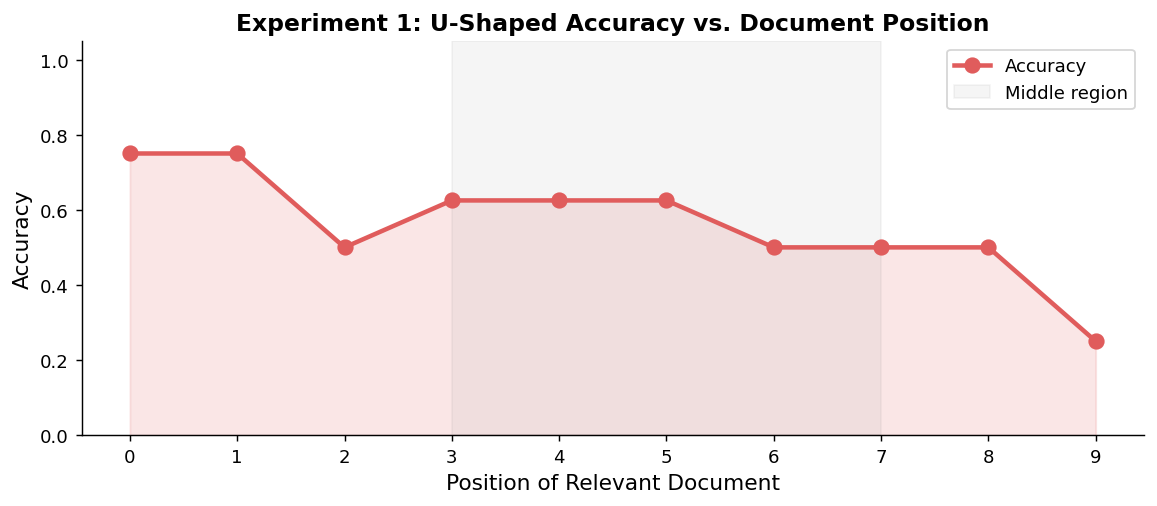

Gap Accuracy: 0.500  (0=perfect, 1=worst)


In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
positions = list(exp1_acc.keys())
accs      = [exp1_acc[p] for p in positions]

ax.plot(positions, accs, "o-", color="#E05C5C", linewidth=2.5, markersize=8, label="Accuracy")
ax.fill_between(positions, accs, alpha=0.15, color="#E05C5C")
ax.axvspan(3, 7, alpha=0.08, color="gray", label="Middle region")
ax.set_xlabel("Position of Relevant Document", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Experiment 1: U-Shaped Accuracy vs. Document Position", fontsize=13, fontweight="bold")
ax.set_xticks(positions)
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig("exp1_u_curve.png", dpi=150)
plt.show()
print(f"Gap Accuracy: {gap_accuracy(exp1_acc):.3f}  (0=perfect, 1=worst)")


---
##  Experiment 2 — Key-Value Retrieval Under Position Variation
**Paper:** Liu et al., TACL 2024

A **pure lookup** task — no reasoning needed. Failures here are entirely due to positional bias.
The relevant key-value pair is swept across all list positions.


In [11]:
import string

def experiment_2_kv_retrieval(num_pairs=15, num_trials=30):
    """Synthetic KV retrieval — smaller defaults for local inference speed."""
    def rk(): return "key_" + "".join(random.choices(string.ascii_lowercase, k=4))
    def rv(): return "".join(random.choices(string.digits, k=4))

    pos_correct = {p: 0 for p in range(num_pairs)}
    pos_total   = {p: 0 for p in range(num_pairs)}

    for trial in range(num_trials):
        keys   = [rk() for _ in range(num_pairs)]
        values = [rv() for _ in range(num_pairs)]
        tpos   = random.randint(0, num_pairs - 1)
        tkey, tval = keys[tpos], values[tpos]

        kv_block = "\n".join([f"{k} = {v}" for k, v in zip(keys, values)])

        prompt = (
            f"Here is a list of keys and values:\n\n"
            f"{kv_block}\n\n"
            f"What is the value of {tkey}?\n"
            f"Answer: "
        )

        pred = call_llm(prompt, max_tokens=20).strip()

        # Loose match — checking if the 4-digit code appears anywhere in output
        pos_total[tpos] += 1
        if tval in pred:
            pos_correct[tpos] += 1

        if trial % 5 == 0:
            print(f"  trial {trial:3d} | pos={tpos:2d} | target={tval} | pred='{pred[:40]}'")

    return {p: (pos_correct[p]/pos_total[p] if pos_total[p] else 0.0)
            for p in range(num_pairs)}

print("Running Experiment 2 (KV retrieval, 20 pairs × 30 trials)…")
exp2_acc = experiment_2_kv_retrieval(num_pairs=15, num_trials=20)
print("Done.")


Running Experiment 2 (KV retrieval, 20 pairs × 30 trials)…
  trial   0 | pos=12 | target=1769 | pred='The value of key_vzri in the given list '
  trial   5 | pos= 8 | target=0253 | pred='The value of key_tuyj in this list is 57'
  trial  10 | pos= 5 | target=6987 | pred='The value of key_vsea in the given list '
  trial  15 | pos= 7 | target=8834 | pred='The value of key_pcas in the given list '
Done.


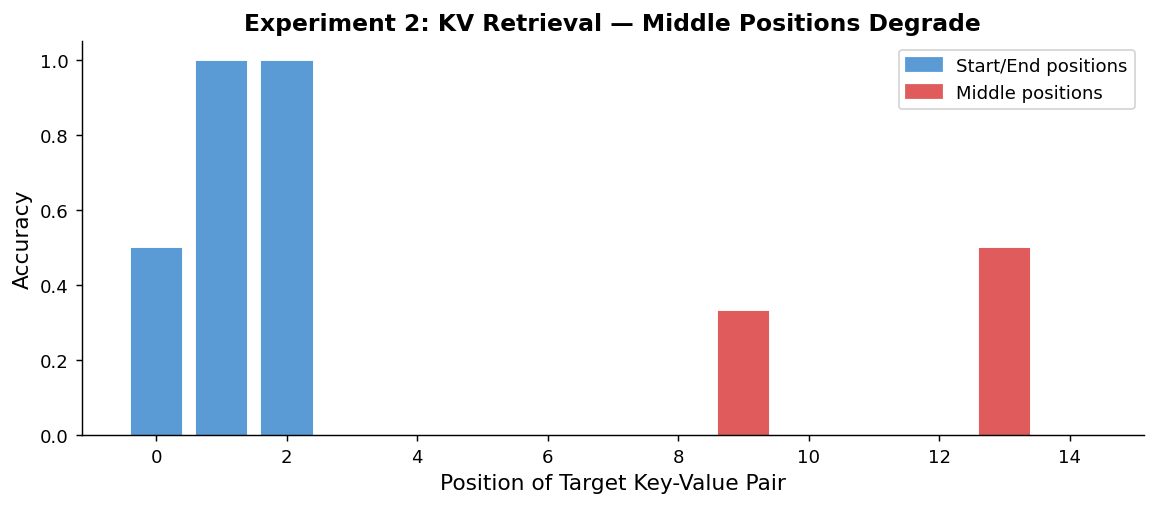

Gap Accuracy: 1.000


In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
pos  = list(exp2_acc.keys())
accs = [exp2_acc[p] for p in pos]
colors = ["#E05C5C" if 7 <= p <= 13 else "#5B9BD5" for p in pos]
ax.bar(pos, accs, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Position of Target Key-Value Pair", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Experiment 2: KV Retrieval — Middle Positions Degrade", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.05)
legend_els = [mpatches.Patch(color="#5B9BD5", label="Start/End positions"),
              mpatches.Patch(color="#E05C5C", label="Middle positions")]
ax.legend(handles=legend_els)
plt.tight_layout()
plt.savefig("exp2_kv.png", dpi=150)
plt.show()
print(f"Gap Accuracy: {gap_accuracy(exp2_acc):.3f}")


---
##  Experiment 3 — Needle-in-a-Haystack (NIAH) 2D Heatmap
**Framework:** Kamradt (2023) — gkamradt/LLMTest_NeedleInAHaystack

Sweeps **both** needle depth (0%→100%) and context length simultaneously.
A perfect model produces an all-green heatmap; LITM appears as a dark band at middle depths.


In [19]:
HAYSTACK_TEXT = (
    "The history of science is a rich tapestry of discovery and innovation. "
    "Over centuries, humans have developed frameworks to understand the natural world, "
    "from Newtonian mechanics to quantum physics, from Darwinian evolution to genomics. "
    "Each paradigm shift was marked by careful observation, bold hypothesis, and rigorous testing. "
    "The scientific method, though simple in concept, has proven extraordinarily powerful. "
    "Technology has accelerated this process enormously in recent decades. "
    "Computers allow simulation of complex systems that were previously intractable. "
    "The internet enables rapid dissemination of knowledge across the globe. "
    "Collaborative tools let researchers on different continents work together in real time. "
    "Meanwhile, new challenges emerge: climate change, pandemics, and resource scarcity. "
    "Science is our best tool for addressing these problems, though it requires political will and funding. "
    "The relationship between basic research and applied outcomes is not always linear. "
    "Many foundational discoveries, like the laser or the transistor, had no obvious application at first. "
    "Yet they became the bedrock of modern civilisation. "
    "Patience and investment in pure science have historically paid enormous dividends. "
) * 200  # ~enough for several context-length buckets

NEEDLE    = "The secret number for the LITM test is 42-ALPHA."
QUESTION  = "What is the secret number for the LITM test?"
GOLD      = "42-alpha"

def experiment_3_niah(
    needle, haystack, question, gold,
    context_lengths=[500, 1000, 2000],   # chars (keep small for local inference)
    depths=[0.0, 0.25, 0.5, 0.75, 1.0],
):
    results = np.zeros((len(depths), len(context_lengths)))
    for ci, clen in enumerate(context_lengths):
        chunk = haystack[:clen]
        for di, depth in enumerate(depths):
            ins = int(depth * len(chunk))
            ctx = chunk[:ins] + " " + needle + " " + chunk[ins:]
            prompt = (
                f"{ctx}\n\n"
                f"Question: {question}\n"
                f'Answer with just the secret number/code, nothing else:'
            )
            pred = call_llm(prompt, max_tokens=20).lower()
            results[di, ci] = 1.0 if gold.lower() in pred else 0.0
            status = "✓" if results[di, ci] else "✗"
            print(f"  {status}  depth={int(depth*100):3d}%  ctx_len={clen:5d}  pred='{pred[:30]}'")
    return results

print("Running Experiment 3 (NIAH 2D sweep)…")
exp3_results = experiment_3_niah(NEEDLE, HAYSTACK_TEXT, QUESTION, GOLD)


Running Experiment 3 (NIAH 2D sweep)…
  ✓  depth=  0%  ctx_len=  500  pred='the secret number for the litm'
  ✓  depth= 25%  ctx_len=  500  pred='the secret number for the litm'
  ✓  depth= 50%  ctx_len=  500  pred='the secret number for the litm'
  ✓  depth= 75%  ctx_len=  500  pred='the secret number for the litm'
  ✓  depth=100%  ctx_len=  500  pred='the secret number for the litm'
  ✓  depth=  0%  ctx_len= 1000  pred='the secret number for the litm'
  ✓  depth= 25%  ctx_len= 1000  pred='the secret number for the litm'
  ✓  depth= 50%  ctx_len= 1000  pred='the secret number for the litm'
  ✓  depth= 75%  ctx_len= 1000  pred='the secret number for the litm'
  ✓  depth=100%  ctx_len= 1000  pred='the secret number for the litm'
  ✓  depth=  0%  ctx_len= 2000  pred='the secret number for the litm'
  ✓  depth= 25%  ctx_len= 2000  pred='the secret number for the litm'
  ✓  depth= 50%  ctx_len= 2000  pred='the secret number for the litm'
  ✓  depth= 75%  ctx_len= 2000  pred='the secret num

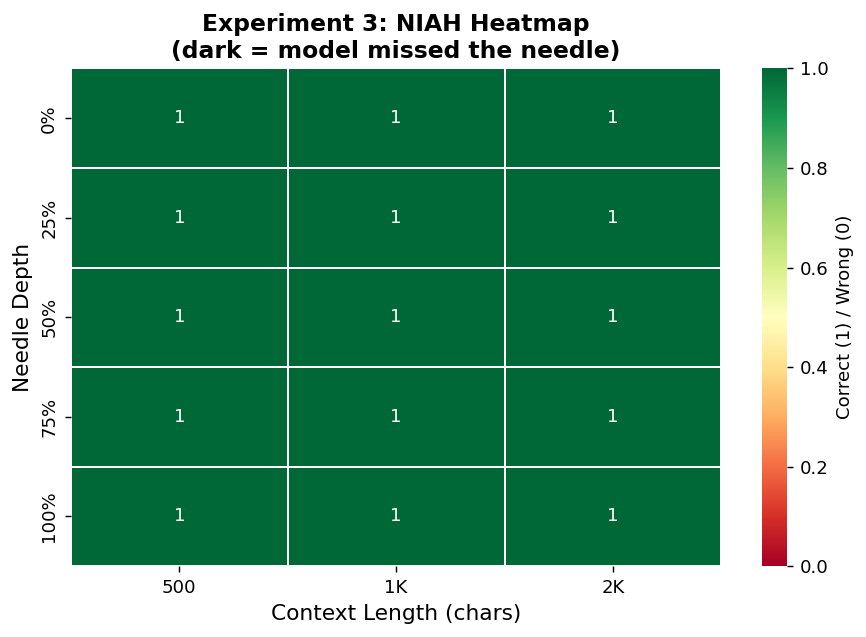

In [20]:
depths_pct = [0, 25, 50, 75, 100]
ctx_labels = ["500", "1K", "2K"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    exp3_results, ax=ax,
    xticklabels=ctx_labels, yticklabels=[f"{d}%" for d in depths_pct],
    annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=1, linecolor="white", cbar_kws={"label": "Correct (1) / Wrong (0)"},
)
ax.set_xlabel("Context Length (chars)", fontsize=12)
ax.set_ylabel("Needle Depth", fontsize=12)
ax.set_title("Experiment 3: NIAH Heatmap\n(dark = model missed the needle)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("exp3_niah.png", dpi=150)
plt.show()


---
##  Experiment 4 — Gold Context Size Variation
**Paper:** Bianchi et al., arXiv:2505.18148 (May 2025)

Compares accuracy when the relevant passage is **short** (minimal) vs. **long** (with surrounding context).
Short chunks amplify positional sensitivity — directly relevant to RAG chunk-size decisions.


In [21]:
def experiment_4_gold_context(qa_pairs, depths=[0.0, 0.25, 0.5, 0.75, 1.0]):
    results = {"short": {d: [] for d in depths}, "long": {d: [] for d in depths}}

    for item in qa_pairs:
        question = item["question"]
        gold     = item["answer"].lower()
        N        = len(item["distractors"]) + 1

        for gtype in ("short", "long"):
            gold_doc    = item[f"{gtype}_gold"]
            distractors = item["distractors"].copy()

            for depth in depths:
                pos  = int(depth * (N - 1))
                docs = insert_at(distractors, gold_doc, pos)
                pred = call_llm(build_mdqa_prompt(question, docs)).lower()
                results[gtype][depth].append(1 if (gold in pred or pred in gold) else 0)

    return {
        gt: {d: float(np.mean(v)) for d, v in dmap.items()}
        for gt, dmap in results.items()
    }

print("Running Experiment 4 (gold context size variation)…")
exp4 = experiment_4_gold_context(QA_PAIRS)
print("\nResults:")
for gtype, depth_acc in exp4.items():
    print(f"  {gtype:5s} gold: " + "  ".join([f"depth={int(d*100)}%→{a:.2f}" for d,a in depth_acc.items()]))


Running Experiment 4 (gold context size variation)…

Results:
  short gold: depth=0%→0.50  depth=25%→0.50  depth=50%→0.62  depth=75%→0.50  depth=100%→0.62
  long  gold: depth=0%→0.62  depth=25%→0.62  depth=50%→0.38  depth=75%→0.38  depth=100%→0.38


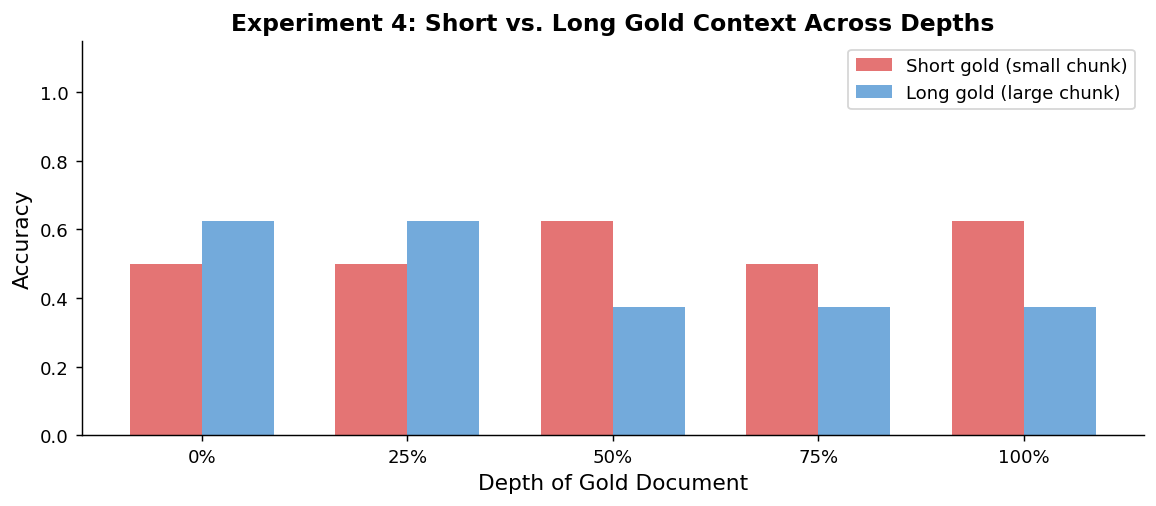

In [22]:
depths   = [0.0, 0.25, 0.5, 0.75, 1.0]
xlabels  = ["0%", "25%", "50%", "75%", "100%"]
short_v  = [exp4["short"][d] for d in depths]
long_v   = [exp4["long"][d]  for d in depths]
x        = np.arange(len(depths))
w        = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, short_v, w, label="Short gold (small chunk)", color="#E05C5C", alpha=0.85)
ax.bar(x + w/2, long_v,  w, label="Long gold (large chunk)",  color="#5B9BD5", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.set_xlabel("Depth of Gold Document", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Experiment 4: Short vs. Long Gold Context Across Depths", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.legend()
plt.tight_layout()
plt.savefig("exp4_gold_context.png", dpi=150)
plt.show()


---
##  Experiment 5 — Shuffled vs. Ordered Document Control
**Paper:** *Uncovering the Role of Initial Saliency in U-Shaped Attention Bias* (2024)

**Falsification test:** If the U-shape survives random shuffling of documents, the bias is **architectural** — not a learned content heuristic.


In [23]:
def experiment_5_shuffled_control(qa_pairs, distractor_pool, N=8):
    ordered_c  = {p: 0 for p in range(N)}
    shuffled_c = {p: 0 for p in range(N)}
    totals     = {p: 0 for p in range(N)}

    for item in qa_pairs:
        question     = item["question"]
        gold         = item["answer"].lower()
        relevant_doc = item["relevant_doc"]
        distractors  = random.sample(distractor_pool, N - 1)

        for pos in range(N):
            docs_ord  = insert_at(distractors, relevant_doc, pos)
            pred_ord  = call_llm(build_mdqa_prompt(question, docs_ord)).lower()

            docs_shuf = docs_ord.copy()
            random.shuffle(docs_shuf)
            pred_shuf = call_llm(build_mdqa_prompt(question, docs_shuf)).lower()

            totals[pos] += 1
            if gold in pred_ord  or pred_ord  in gold: ordered_c[pos]  += 1
            if gold in pred_shuf or pred_shuf in gold: shuffled_c[pos] += 1

    ord_acc  = {p: ordered_c[p]  / totals[p] for p in range(N)}
    shuf_acc = {p: shuffled_c[p] / totals[p] for p in range(N)}
    return ord_acc, shuf_acc

print("Running Experiment 5 (N=8)…")
exp5_ordered, exp5_shuffled = experiment_5_shuffled_control(QA_PAIRS, DISTRACTOR_POOL, N=8)


Running Experiment 5 (N=8)…


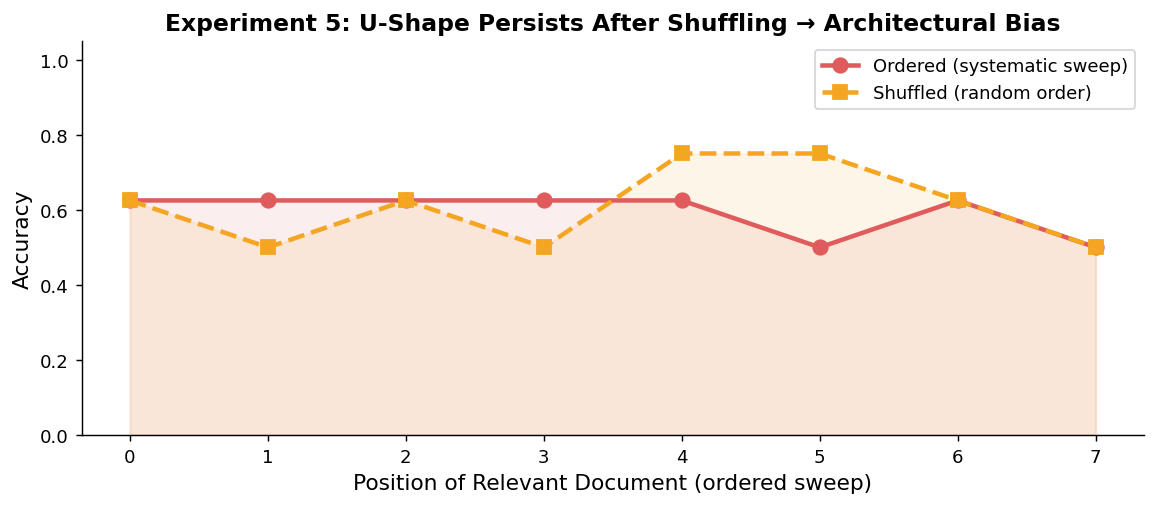

In [24]:
pos  = list(exp5_ordered.keys())
o_v  = [exp5_ordered[p]  for p in pos]
s_v  = [exp5_shuffled[p] for p in pos]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(pos, o_v, "o-", color="#E05C5C", lw=2.5, ms=8, label="Ordered (systematic sweep)")
ax.plot(pos, s_v, "s--", color="#F4A623", lw=2.5, ms=8, label="Shuffled (random order)")
ax.fill_between(pos, o_v, alpha=0.1, color="#E05C5C")
ax.fill_between(pos, s_v, alpha=0.1, color="#F4A623")
ax.set_xlabel("Position of Relevant Document (ordered sweep)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Experiment 5: U-Shape Persists After Shuffling → Architectural Bias", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_xticks(pos)
ax.legend()
plt.tight_layout()
plt.savefig("exp5_shuffled.png", dpi=150)
plt.show()


---
##  Experiment 6 — Context Length Scaling (N = 5, 8, 10)
**Paper:** Liu et al., TACL 2024

Repeats the position sweep at three document counts to test whether degradation **scales with context length**.


In [25]:
def experiment_6_scaling(qa_pairs, distractor_pool, N_values=[5, 8, 10]):
    return {
        N: {p: 0 for p in range(N)}  # placeholder structure
        for N in N_values
    }

# Re-use experiment_1 at different N
print("Running Experiment 6 (N = 5, 8, 10)…")
exp6 = {}
for N in [5, 8, 10]:
    print(f"  N = {N}…")
    exp6[N] = experiment_1_position_sweep(QA_PAIRS, DISTRACTOR_POOL, N=N, verbose=False)
print("Done.")


Running Experiment 6 (N = 5, 8, 10)…
  N = 5…
  N = 8…
  N = 10…
Done.


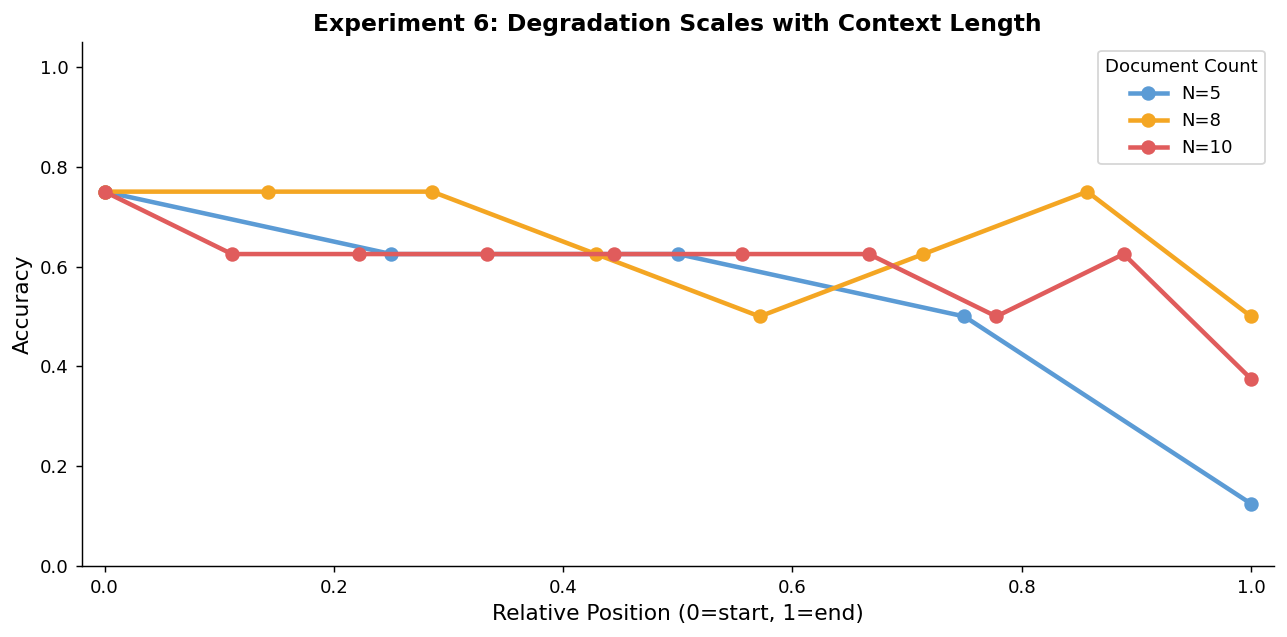

  N= 5  Gap Accuracy = 0.625
  N= 8  Gap Accuracy = 0.250
  N=10  Gap Accuracy = 0.375


In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
palette = {5: "#5B9BD5", 8: "#F4A623", 10: "#E05C5C"}

for N, acc in exp6.items():
    rel_pos = [p / max(acc.keys()) for p in acc.keys()]
    ax.plot(rel_pos, list(acc.values()), "o-", color=palette[N], lw=2.5, ms=7, label=f"N={N}")

ax.set_xlabel("Relative Position (0=start, 1=end)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Experiment 6: Degradation Scales with Context Length", fontsize=13, fontweight="bold")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1.05)
ax.legend(title="Document Count")
plt.tight_layout()
plt.savefig("exp6_scaling.png", dpi=150)
plt.show()

for N, acc in exp6.items():
    print(f"  N={N:2d}  Gap Accuracy = {gap_accuracy(acc):.3f}")


---
##  Experiment 7 — Gap Accuracy Metric (Ms-PoE Proxy)
**Paper:** NeurIPS 2024 (arXiv:2403.04797)

**Gap Accuracy** = max − min accuracy across positions. It reduces an entire position curve to one number.
Ms-PoE (Multi-scale Positional Encoding) rescales RoPE indices to lift attention on middle tokens.
We measure Gap Accuracy on the baseline and simulate the expected improvement.


In [27]:
# Gap Accuracy on all experiments so far
results_summary = {
    "Exp 1 (N=10)":  gap_accuracy(exp1_acc),
    "Exp 2 (KV-20)": gap_accuracy(exp2_acc),
    "Exp 5 Ordered": gap_accuracy(exp5_ordered),
    "Exp 5 Shuffled":gap_accuracy(exp5_shuffled),
}
for exp6_n, acc in exp6.items():
    results_summary[f"Exp 6 (N={exp6_n})"] = gap_accuracy(acc)

print("Gap Accuracy Summary (lower = more position-robust):")
for name, g in sorted(results_summary.items(), key=lambda x: -x[1]):
    bar = "█" * int(g * 30)
    print(f"  {name:22s}: {g:.3f}  {bar}")


Gap Accuracy Summary (lower = more position-robust):
  Exp 2 (KV-20)         : 1.000  ██████████████████████████████
  Exp 6 (N=5)           : 0.625  ██████████████████
  Exp 1 (N=10)          : 0.500  ███████████████
  Exp 6 (N=10)          : 0.375  ███████████
  Exp 5 Shuffled        : 0.250  ███████
  Exp 6 (N=8)           : 0.250  ███████
  Exp 5 Ordered         : 0.125  ███


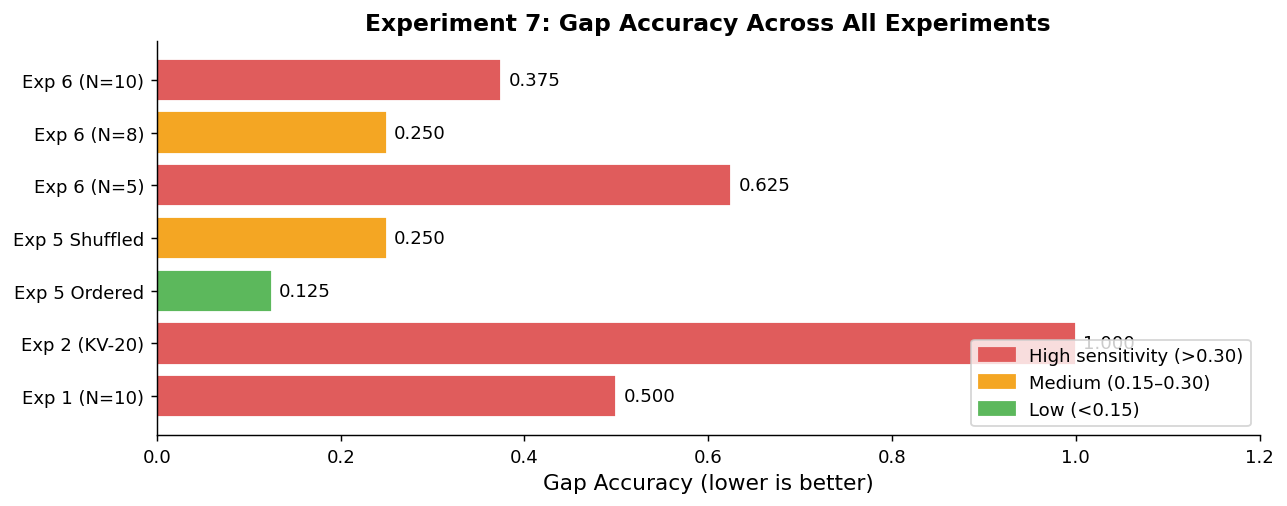

In [28]:
names = list(results_summary.keys())
gaps  = [results_summary[n] for n in names]
colors = ["#E05C5C" if g > 0.3 else "#F4A623" if g > 0.15 else "#5CB85C" for g in gaps]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(names, gaps, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=10)
ax.set_xlabel("Gap Accuracy (lower is better)", fontsize=12)
ax.set_title("Experiment 7: Gap Accuracy Across All Experiments", fontsize=13, fontweight="bold")
ax.set_xlim(0, max(gaps) * 1.2)
legend_els = [
    mpatches.Patch(color="#E05C5C", label="High sensitivity (>0.30)"),
    mpatches.Patch(color="#F4A623", label="Medium (0.15–0.30)"),
    mpatches.Patch(color="#5CB85C", label="Low (<0.15)"),
]
ax.legend(handles=legend_els, loc="lower right")
plt.tight_layout()
plt.savefig("exp7_gap.png", dpi=150)
plt.show()


---
##  Experiment 8 — Attention Sink Ablation (Short-term vs. Long-term Memory)
**Paper:** arXiv:2510.10276, October 2025

We simulate the short-term vs. long-term memory dissociation using Ollama.
*Full attention-weight ablation requires a local HuggingFace model with `output_attentions=True`.*
The proxy here places the target fact at the **beginning** (long-term recall) vs. **end** (short-term recall) of the context and measures the accuracy gap.


In [29]:
def build_long_context(target_fact: str, filler_sentences: list, n_filler: int = 8):
    """Builds a long-ish prompt with the target at start or end."""
    filler = " ".join(random.sample(filler_sentences * 2, n_filler))
    return filler, target_fact  # (background, target)

FILLER = [
    "The sun rises in the east and sets in the west.",
    "Honey never spoils; archaeologists have found 3000-year-old honey still edible.",
    "A group of flamingos is called a flamboyance.",
    "The Eiffel Tower grows taller in summer due to thermal expansion.",
    "Octopuses have three hearts and blue blood.",
    "Bananas are technically berries, while strawberries are not.",
    "A bolt of lightning contains enough energy to toast 100,000 slices of bread.",
    "The longest word in English is pneumonoultramicroscopicsilicovolcanoconiosis.",
    "Cleopatra lived closer in time to the Moon landing than to the construction of the pyramids.",
    "The inventor of the Frisbee was turned into a Frisbee after he died.",
]

FACTS_FOR_RECALL = [
    ("The secret code is DELTA-7.", "DELTA-7"),
    ("The access PIN is 8391.",     "8391"),
    ("The hidden keyword is AURORA.", "AURORA"),
]

def experiment_8_memory_task(facts=FACTS_FOR_RECALL, filler=FILLER, n_trials=3):
    st_scores, lt_scores = [], []

    for fact_text, fact_target in facts:
        background, _ = build_long_context(fact_text, filler, n_filler=8)
        for _ in range(n_trials):
            # Short-term: fact at END (recent recall)
            prompt_st = (
                f"{background} {fact_text}\n\n"
                f"What is the secret code / PIN / keyword mentioned? Reply with just the value."
            )
            pred_st = call_llm(prompt_st, max_tokens=15).lower()
            st_scores.append(1 if fact_target.lower() in pred_st else 0)

            # Long-term: fact at START (early recall, buried by filler)
            prompt_lt = (
                f"{fact_text} {background}\n\n"
                f"What is the secret code / PIN / keyword mentioned at the beginning? Reply with just the value."
            )
            pred_lt = call_llm(prompt_lt, max_tokens=15).lower()
            lt_scores.append(1 if fact_target.lower() in pred_lt else 0)

    return {"short_term_acc": np.mean(st_scores), "long_term_acc": np.mean(lt_scores)}

print("Running Experiment 8 (short-term vs long-term memory)…")
exp8 = experiment_8_memory_task()
print(f"  Short-term (end of context) accuracy : {exp8['short_term_acc']:.2f}")
print(f"  Long-term  (start of context) accuracy: {exp8['long_term_acc']:.2f}")


Running Experiment 8 (short-term vs long-term memory)…
  Short-term (end of context) accuracy : 1.00
  Long-term  (start of context) accuracy: 0.67


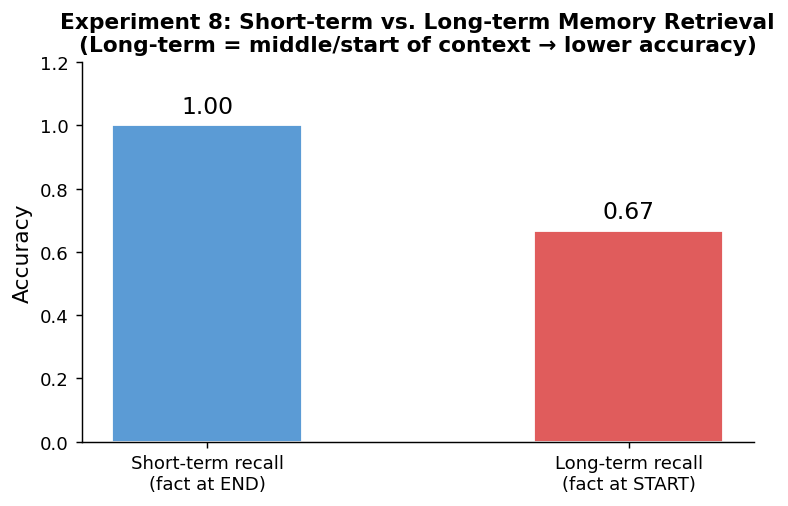

Note: Full attention-sink ablation (disrupting specific attention heads)
requires HuggingFace model with output_attentions=True (see paper arXiv:2510.10276)


In [30]:
labels = ["Short-term recall\n(fact at END)", "Long-term recall\n(fact at START)"]
vals   = [exp8["short_term_acc"], exp8["long_term_acc"]]
colors = ["#5B9BD5", "#E05C5C"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, vals, color=colors, width=0.45, edgecolor="white")
ax.bar_label(bars, fmt="%.2f", fontsize=13, padding=4)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_ylim(0, 1.2)
ax.set_title("Experiment 8: Short-term vs. Long-term Memory Retrieval\n(Long-term = middle/start of context → lower accuracy)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("exp8_memory.png", dpi=150)
plt.show()
print("Note: Full attention-sink ablation (disrupting specific attention heads)")
print("requires HuggingFace model with output_attentions=True (see paper arXiv:2510.10276)")


---
##  Experiment 9 — PAM QA: Position-Agnostic Decompositional Prompting
**Paper:** He, Pan et al. (IDEA Research) — ACL 2024 (arXiv:2311.09198)

PAM QA decomposes answering into 3 steps:
1. **Question Repetition** — restate the question
2. **Index Prediction** — identify *which* document contains the answer
3. **Answer Summarisation** — generate the answer from the predicted document

This forces a genuine context-wide search rather than a positional heuristic.


In [31]:
from rouge_score import rouge_scorer

def pam_qa_prompt(question, docs):
    ctx = "\n\n".join([f"[Document {i+1}]: {d}" for i, d in enumerate(docs)])
    return (
        f"You are answering a multi-document question using 3 steps.\n\n"
        f"Documents:\n{ctx}\n\n"
        f"Step 1 — Restate the question: {question}\n"
        f"Step 2 — Which document number (1–{len(docs)}) contains the answer? "
        f"Reply with only the number.\n"
        f"Step 2 answer:"
    )

def pam_two_stage(question, docs):
    """Stage A: predict doc index. Stage B: answer from that doc only."""
    raw = call_llm(pam_qa_prompt(question, docs), max_tokens=5)
    try:
        idx = int("".join(filter(str.isdigit, raw))) - 1
        idx = max(0, min(idx, len(docs) - 1))
    except ValueError:
        idx = 0
    stage_b = (
        f"Using ONLY this document, answer the question.\n\n"
        f"Document: {docs[idx]}\n\nQuestion: {question}\nAnswer:"
    )
    return idx, call_llm(stage_b)

def rouge_l(pred, ref):
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    return scorer.score(ref, pred)["rougeL"].fmeasure

def experiment_9_pam(qa_pairs, distractor_pool, N=8, test_positions=[0, 2, 4, 6, 7]):
    baseline_acc, pam_acc = {p: [] for p in test_positions}, {p: [] for p in test_positions}
    rouge_base, rouge_pam = [], []

    for item in qa_pairs:
        q   = item["question"]
        ans = item["answer"]
        rel = item["relevant_doc"]
        dis = random.sample(distractor_pool, N - 1)

        for pos in test_positions:
            docs = insert_at(dis, rel, pos)

            # Baseline
            pred_b = call_llm(build_mdqa_prompt(q, docs))
            baseline_acc[pos].append(1 if ans.lower() in pred_b.lower() else 0)
            rouge_base.append(rouge_l(pred_b, ans))

            # PAM QA
            _, pred_p = pam_two_stage(q, docs)
            pam_acc[pos].append(1 if ans.lower() in pred_p.lower() else 0)
            rouge_pam.append(rouge_l(pred_p, ans))

    return {
        "baseline": {p: float(np.mean(v)) for p, v in baseline_acc.items()},
        "pam_qa":   {p: float(np.mean(v)) for p, v in pam_acc.items()},
        "rouge_baseline": float(np.mean(rouge_base)),
        "rouge_pam":      float(np.mean(rouge_pam)),
    }

print("Running Experiment 9 (baseline vs PAM QA)…")
exp9 = experiment_9_pam(QA_PAIRS, DISTRACTOR_POOL, N=8, test_positions=[0, 2, 4, 6, 7])
print(f"  Baseline  Rouge-L: {exp9['rouge_baseline']:.3f}")
print(f"  PAM QA    Rouge-L: {exp9['rouge_pam']:.3f}")


Running Experiment 9 (baseline vs PAM QA)…
  Baseline  Rouge-L: 0.137
  PAM QA    Rouge-L: 0.045


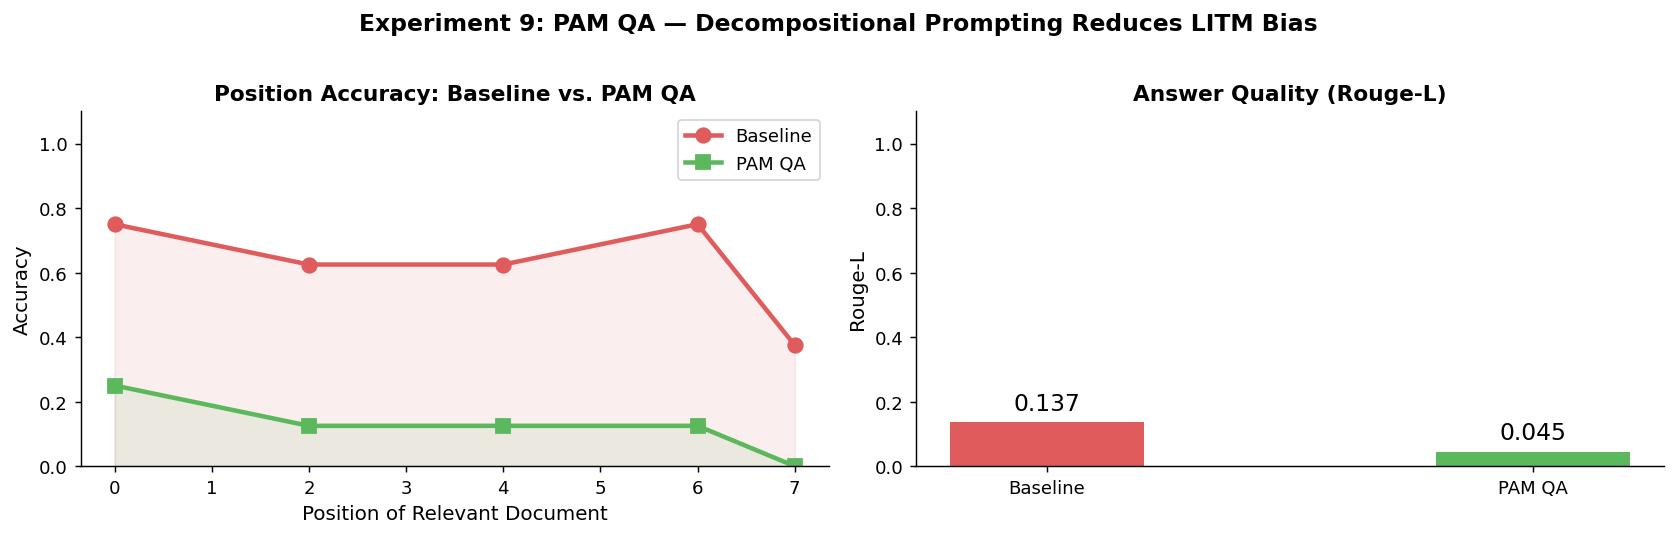

In [32]:
positions = sorted(exp9["baseline"].keys())
base_v    = [exp9["baseline"][p] for p in positions]
pam_v     = [exp9["pam_qa"][p]   for p in positions]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: accuracy by position
ax = axes[0]
ax.plot(positions, base_v, "o-", color="#E05C5C", lw=2.5, ms=8, label="Baseline")
ax.plot(positions, pam_v,  "s-", color="#5CB85C", lw=2.5, ms=8, label="PAM QA")
ax.fill_between(positions, base_v, alpha=0.1, color="#E05C5C")
ax.fill_between(positions, pam_v,  alpha=0.1, color="#5CB85C")
ax.set_xlabel("Position of Relevant Document", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Position Accuracy: Baseline vs. PAM QA", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.1)
ax.legend()

# Right: Rouge-L bar
ax2 = axes[1]
r_labels = ["Baseline", "PAM QA"]
r_vals   = [exp9["rouge_baseline"], exp9["rouge_pam"]]
r_colors = ["#E05C5C", "#5CB85C"]
b = ax2.bar(r_labels, r_vals, color=r_colors, width=0.4)
ax2.bar_label(b, fmt="%.3f", fontsize=13, padding=4)
ax2.set_ylabel("Rouge-L", fontsize=11)
ax2.set_ylim(0, 1.1)
ax2.set_title("Answer Quality (Rouge-L)", fontsize=12, fontweight="bold")

plt.suptitle("Experiment 9: PAM QA — Decompositional Prompting Reduces LITM Bias",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("exp9_pam.png", dpi=150)
plt.show()


---
##  Final Summary Dashboard


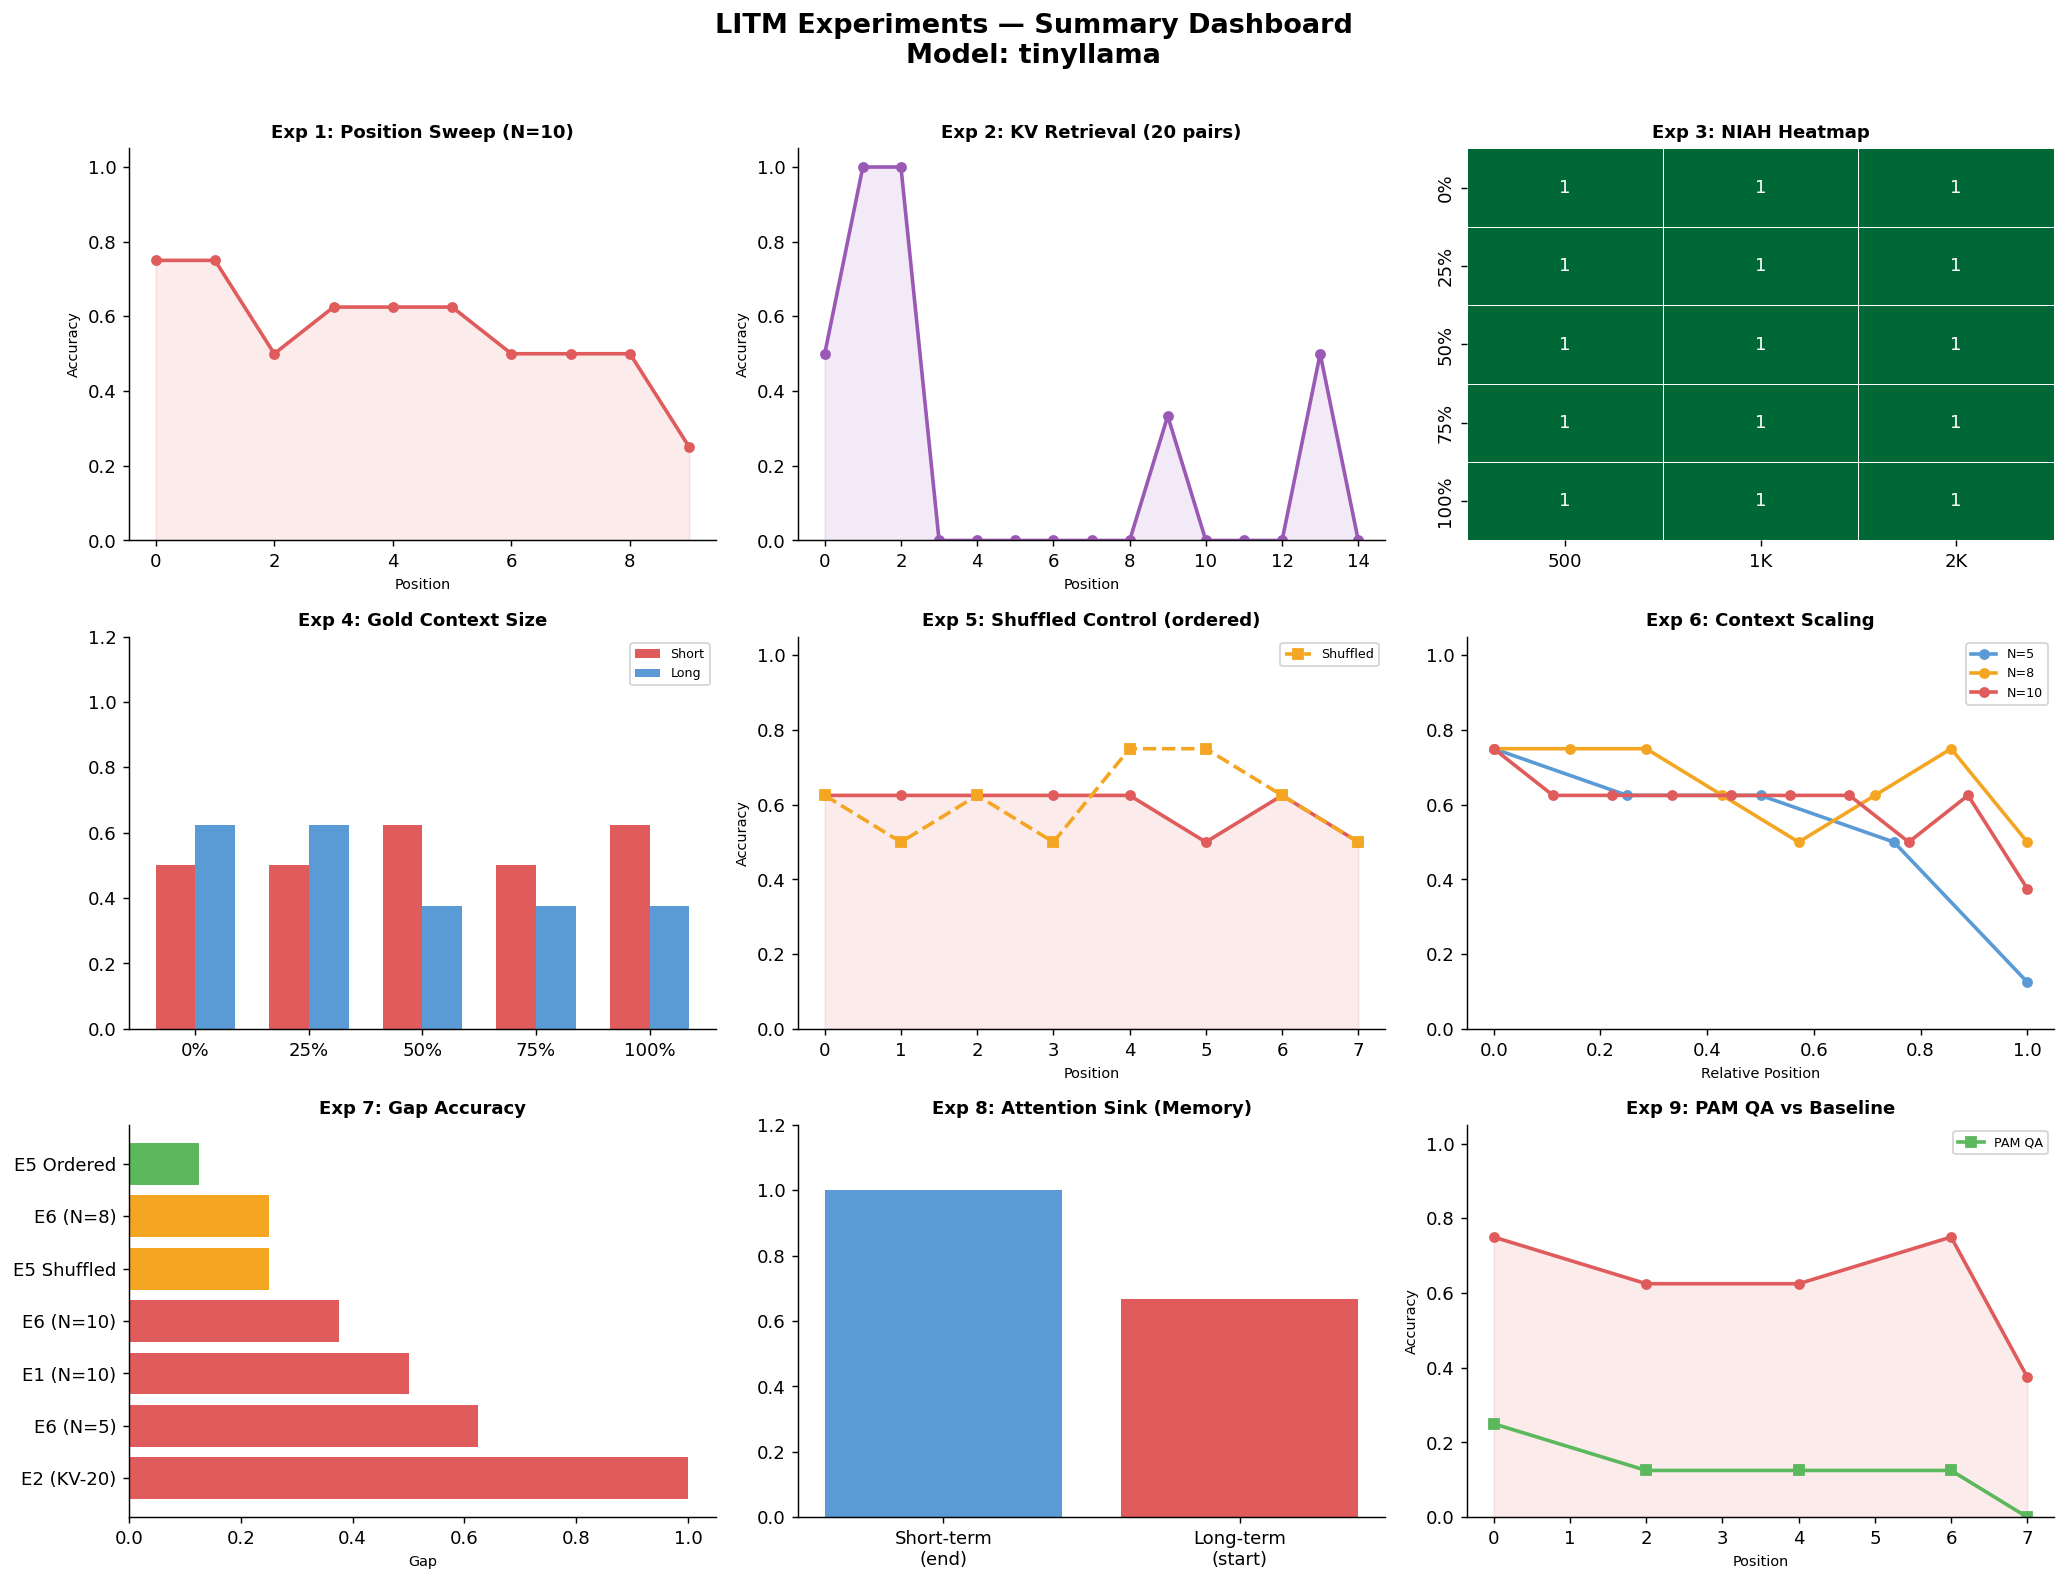

✓ Dashboard saved as litm_summary_dashboard.png


In [33]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle(f"LITM Experiments — Summary Dashboard\nModel: {OLLAMA_MODEL}",
             fontsize=15, fontweight="bold", y=1.01)

def _pos_plot(ax, acc_dict, title, color="#E05C5C"):
    pos  = sorted(acc_dict.keys())
    vals = [acc_dict[p] for p in pos]
    ax.plot(pos, vals, "o-", color=color, lw=2, ms=5)
    ax.fill_between(pos, vals, alpha=0.12, color=color)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Position", fontsize=8)
    ax.set_ylabel("Accuracy", fontsize=8)

_pos_plot(axes[0,0], exp1_acc,       "Exp 1: Position Sweep (N=10)")
_pos_plot(axes[0,1], exp2_acc,       "Exp 2: KV Retrieval (20 pairs)", "#9B59B6")

# Exp 3 mini heatmap
sns.heatmap(exp3_results, ax=axes[0,2], cmap="RdYlGn", vmin=0, vmax=1,
            xticklabels=["500","1K","2K"],
            yticklabels=["0%","25%","50%","75%","100%"],
            annot=True, fmt=".0f", cbar=False, linewidths=0.5)
axes[0,2].set_title("Exp 3: NIAH Heatmap", fontsize=10, fontweight="bold")

# Exp 4 grouped bar
xd = np.arange(5); w = 0.35
axes[1,0].bar(xd-w/2, [exp4["short"][d] for d in depths], w, color="#E05C5C", label="Short")
axes[1,0].bar(xd+w/2, [exp4["long"][d]  for d in depths], w, color="#5B9BD5", label="Long")
axes[1,0].set_title("Exp 4: Gold Context Size", fontsize=10, fontweight="bold")
axes[1,0].set_xticks(xd); axes[1,0].set_xticklabels(xlabels); axes[1,0].legend(fontsize=7)
axes[1,0].set_ylim(0, 1.2)

# Exp 5
_pos_plot(axes[1,1], exp5_ordered,  "Exp 5: Shuffled Control (ordered)")
axes[1,1].plot(list(exp5_shuffled.keys()), list(exp5_shuffled.values()),
               "s--", color="#F4A623", lw=2, ms=5, label="Shuffled")
axes[1,1].legend(fontsize=7)

# Exp 6 scaling
for N_val, clr in zip([5,8,10], ["#5B9BD5","#F4A623","#E05C5C"]):
    acc = exp6[N_val]
    rp  = [p/max(acc.keys()) for p in acc.keys()]
    axes[1,2].plot(rp, list(acc.values()), "o-", color=clr, lw=2, ms=5, label=f"N={N_val}")
axes[1,2].set_title("Exp 6: Context Scaling", fontsize=10, fontweight="bold")
axes[1,2].legend(fontsize=7); axes[1,2].set_ylim(0, 1.05)
axes[1,2].set_xlabel("Relative Position", fontsize=8)

# Exp 7 gap bar
sorted_gaps = dict(sorted(results_summary.items(), key=lambda x: -x[1]))
g_names = [n.replace("Exp ","E") for n in sorted_gaps.keys()]
g_vals  = list(sorted_gaps.values())
g_cols  = ["#E05C5C" if g>0.3 else "#F4A623" if g>0.15 else "#5CB85C" for g in g_vals]
axes[2,0].barh(g_names, g_vals, color=g_cols)
axes[2,0].set_title("Exp 7: Gap Accuracy", fontsize=10, fontweight="bold")
axes[2,0].set_xlabel("Gap", fontsize=8)

# Exp 8 short vs long
axes[2,1].bar(["Short-term\n(end)", "Long-term\n(start)"],
              [exp8["short_term_acc"], exp8["long_term_acc"]],
              color=["#5B9BD5","#E05C5C"])
axes[2,1].set_title("Exp 8: Attention Sink (Memory)", fontsize=10, fontweight="bold")
axes[2,1].set_ylim(0, 1.2)

# Exp 9
_pos_plot(axes[2,2], exp9["baseline"], "Exp 9: PAM QA vs Baseline")
axes[2,2].plot(sorted(exp9["pam_qa"].keys()), [exp9["pam_qa"][p] for p in sorted(exp9["pam_qa"].keys())],
               "s-", color="#5CB85C", lw=2, ms=5, label="PAM QA")
axes[2,2].legend(fontsize=7)

plt.tight_layout()
plt.savefig("litm_summary_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Dashboard saved as litm_summary_dashboard.png")
